# Figure 2


## Setup


In [1]:
library(ggplot2)
library(patchwork)
library(cowplot)
library(dplyr)
library(tidyr)
library(scales)
library(ggrepel)
library(stringr)
library(yaml)
library(here)
library(grid)
library(forcats)
library(tibble)

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”



Attaching package: ‘cowplot’




The following object is masked from ‘package:patchwork’:

    align_plots




Warning message:
“package ‘dplyr’ was built under R version 4.3.3”



Attaching package: ‘dplyr’




...

Warning message:
“package ‘yaml’ was built under R version 4.3.3”


Warning message:
“package ‘here’ was built under R version 4.3.3”


here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



Warning message:
“package ‘forcats’ was built under R version 4.3.3”


Warning message:
“package ‘tibble’ was built under R version 4.3.3”


## Styling and helpers


In [2]:
AXIS_TITLE_SIZE  <- 7 
AXIS_LABEL_SIZE  <- 5.0
PLOT_TITLE_SIZE  <- 5.8
LEGEND_TEXT_SIZE  <- 5.0
LEGEND_TITLE_SIZE <- 6.0
PANEL_C_LABEL_SIZE <- 3.8
PANEL_C_AXIS_TITLE_SIZE <- 5.8
PANEL_C_TITLE_SIZE <- 5.0
PANEL_E_LABEL_SIZE <- PANEL_C_LABEL_SIZE
DOT_SIZE_RANGE  <- c(0.55, 1.65)
ROW2_FILL_LIMITS <- c(0, 15)
ROW2_FILL_BREAKS <- c(0, 5, 10, 15)
LV_FILL_LIMITS   <- c(0, 3)
LV_FILL_BREAKS   <- c(0, 1, 2, 3)

theme_pub <- function(base_size = 7, base_line_size = 0.35) {
    theme_classic(base_size = base_size, base_family = 'Helvetica') %+replace%
    theme(
        plot.title         = element_text(size = PLOT_TITLE_SIZE, face = 'plain', hjust = 0.5,
                                          margin = margin(b = 2)),
        axis.line          = element_line(linewidth = base_line_size),
        axis.ticks         = element_line(linewidth = base_line_size),
        axis.text          = element_text(size = AXIS_LABEL_SIZE),
        axis.title         = element_text(size = AXIS_TITLE_SIZE, face = 'plain',
                                          margin = margin(t = 0, r = 0, b = 0, l = 0)),
        legend.text        = element_text(size = LEGEND_TEXT_SIZE),
        legend.title       = element_text(size = LEGEND_TITLE_SIZE, face = 'plain'),
        legend.key.size    = unit(3, 'mm'),
        legend.background  = element_blank(),
        legend.key         = element_blank(),
        legend.position    = 'right',
        panel.grid         = element_blank(),
        strip.text         = element_text(size = PLOT_TITLE_SIZE, face = 'plain'),
        strip.background   = element_blank(),
        plot.margin        = unit(c(1, 2, 1, 1), 'mm')
    )
}

bubble_theme <- function(show_y_title = TRUE, extra_left_margin = 2) {
    theme_minimal(base_size = 6, base_family = 'Helvetica') +
        theme(
            plot.title         = element_text(size = PLOT_TITLE_SIZE, face = 'plain', hjust = 0.5,
                                              margin = margin(b = 1.5)),
            axis.title.y       = if (show_y_title) {
                element_text(size = AXIS_TITLE_SIZE, face = 'plain', margin = margin(r = extra_left_margin))
            } else {
                element_blank()
            },
            axis.title.x       = element_text(size = AXIS_TITLE_SIZE, face = 'plain', margin = margin(t = 0.2)),
            axis.text.x        = element_text(size = AXIS_LABEL_SIZE),
            axis.text.y        = element_text(size = AXIS_LABEL_SIZE, lineheight = 0.90),
            panel.grid.major.x = element_line(color = 'grey88', linewidth = 0.3),
            panel.grid.major.y = element_line(color = 'grey88', linewidth = 0.3),
            panel.grid.minor   = element_blank(),
            panel.border       = element_rect(color = 'grey70', fill = NA, linewidth = 0.45),
            legend.position    = 'none',
            plot.margin        = margin(2.0, 1.2, 2.2, 1.0)
        )
}

panel_c_text_theme <- function() {
    theme(
        axis.text.x  = element_text(size = PANEL_C_LABEL_SIZE),
        axis.text.y  = element_text(size = PANEL_C_LABEL_SIZE, lineheight = 0.95, vjust = 0.5),
        axis.title.x = element_text(size = PANEL_C_AXIS_TITLE_SIZE, face = 'plain', margin = margin(t = 0.1)),
        plot.title   = element_text(size = PANEL_C_TITLE_SIZE, face = 'plain', hjust = 0.5,
                                    margin = margin(b = 1.0))
    )
}

cfg <- yaml::read_yaml(here('config.yaml'))
MODEL_COLORS           <- setNames(unlist(cfg$MODEL_COLORS),           names(cfg$MODEL_COLORS))
RNASEQ_FRACTION_COLORS <- setNames(unlist(cfg$RNASEQ_FRACTION_COLORS), names(cfg$RNASEQ_FRACTION_COLORS))
CT_COLORS              <- setNames(unlist(cfg$CELL_TYPE_COLORS),       names(cfg$CELL_TYPE_COLORS))
CT_LABELS              <- setNames(unlist(cfg$CELL_TYPE_LABELS),       names(cfg$CELL_TYPE_LABELS))
GREEN_COLS <- c('#d9e6e2', '#4bc17c', '#007a33')
PANEL_DIR  <- here('output/99_panels/fig2')


In [3]:
fmt_q <- function(q) {
    if (q >= 0.05) {
        '"ns"'
    } else if (q >= 0.001) {
        sprintf('"%.3f"', q)
    } else {
        e_str    <- formatC(q, format = 'e', digits = 1)
        parts    <- strsplit(e_str, 'e')[[1]]
        mantissa <- trimws(parts[1])
        exp_val  <- as.integer(parts[2])
        sprintf('%s%%*%%10^{%d}', mantissa, exp_val)
    }
}

pick_top_unique <- function(df, label_col, x_col, top_n = 3) {
    df <- df[order(df[[x_col]], decreasing = TRUE, na.last = TRUE), , drop = FALSE]
    df <- df[!duplicated(df[[label_col]]), , drop = FALSE]
    head(df, top_n)
}

pad_to_n <- function(df, label_col, n = 3) {
    i <- 1
    while (nrow(df) < n) {
        pad <- df[1, , drop = FALSE]
        pad[,] <- NA
        pad[[label_col]] <- paste(rep(' ', i), collapse = '')
        df <- rbind(df, pad)
        i  <- i + 1
    }
    df
}

compose_with_bottom_legend <- function(core_plot, legend_grob, legend_height = 0.12) {
    plot_grid(core_plot, legend_grob, ncol = 1, rel_heights = c(1, legend_height))
}

compose_with_top_legend <- function(core_plot, legend_grob, legend_height = 0.08) {
    plot_grid(legend_grob, core_plot, ncol = 1, rel_heights = c(legend_height, 1))
}

dot_fill_scale <- function(limits, breaks) {
    scale_fill_gradient(
        low = '#d9efe0', high = '#0b7d29', name = '-log10 FDR',
        limits = limits, breaks = breaks, oob = scales::squish
    )
}

legend_theme_shared <- function() {
    theme(
        legend.position   = 'top',
        legend.direction  = 'horizontal',
        legend.justification = 'center',
        legend.box.just      = 'center',
        legend.box           = 'horizontal',
        legend.spacing.x     = unit(2, 'mm'),
        legend.title      = element_text(size = LEGEND_TITLE_SIZE, family = 'Helvetica', face = 'plain', hjust = 0.5),
        legend.text       = element_text(size = LEGEND_TEXT_SIZE, family = 'Helvetica'),
        legend.margin     = margin(0, 0, 0, 0),
        legend.box.margin = margin(0, 2, 0, 0),
        legend.background = element_blank(),
        legend.key        = element_blank(),
        plot.margin       = margin(0, 0, 0, 0)
    )
}

make_dotplot_colorbar <- function(limits = ROW2_FILL_LIMITS, breaks = ROW2_FILL_BREAKS) {
    legend_df <- tibble(x = seq_along(breaks), y = 1, neg_log10_fdr = breaks)
    legend_plot <- ggplot(legend_df, aes(x, y, fill = neg_log10_fdr)) +
        geom_point(shape = 21, size = 0.1, colour = NA) +
        dot_fill_scale(limits, breaks) +
        guides(fill = guide_colourbar(title.position = 'top', title.hjust = 0.5, title.vjust = 0.5,
                                     barwidth = unit(2.1, 'cm'), barheight = unit(0.25, 'cm'),
                                     frame.colour = 'black', ticks.colour = 'black')) +
        theme_void(base_family = 'Helvetica') +
        legend_theme_shared()
    legend_plot
}

make_panel_c_legend_right <- function(limits = ROW2_FILL_LIMITS, breaks = ROW2_FILL_BREAKS) {
    size_breaks <- breaks[breaks > 0]
    n_breaks    <- length(size_breaks)
    key_sizes   <- seq(0.9, 3.5, length.out = n_breaks)

    legend_df <- tibble(x = 1, y = seq_along(breaks), neg_log10_fdr = breaks)
    ggplot(legend_df, aes(x, y, fill = neg_log10_fdr, size = neg_log10_fdr)) +
        geom_point(shape = 21, stroke = 0.2, colour = 'black') +
        scale_size_continuous(limits = limits, range = DOT_SIZE_RANGE, breaks = size_breaks) +
        dot_fill_scale(limits, breaks) +
        guides(
            fill = guide_colourbar(
                title = '-log10\nFDR',
                title.position = 'top', title.vjust = 0.5,
                barheight = unit(2.2, 'cm'), barwidth = unit(0.28, 'cm'),
                frame.colour = 'black', ticks.colour = 'black'),
            size = guide_legend(
                title = 'N', title.position = 'top',
                label.position = 'right', direction = 'vertical',
                override.aes = list(shape = 21, colour = 'black', stroke = 0.2,
                                    fill = '#4bc17c', size = key_sizes))
        ) +
        theme_void(base_family = 'Helvetica') +
        theme(
            legend.position   = 'right',
            legend.direction  = 'vertical',
            legend.box        = 'vertical',
            legend.spacing.y  = unit(4, 'mm'),
            legend.title      = element_text(size = LEGEND_TITLE_SIZE, family = 'Helvetica',
                                             face = 'plain', hjust = 0.5),
            legend.text       = element_text(size = LEGEND_TEXT_SIZE, family = 'Helvetica'),
            legend.margin     = margin(0, 0, 0, 2),
            legend.box.margin = margin(0, 0, 0, 0),
            legend.background = element_blank(),
            legend.key        = element_blank(),
            plot.margin       = margin(2, 2, 2, 2)
        )
}

make_heatmap_legend <- function() {
    legend_df <- tibble(x = c(1, 2, 3), y = 1, pct = c(0, 50, 100))
    ggplot(legend_df, aes(x = x, y = y, fill = pct)) +
        geom_point(shape = 21, size = 0.1, colour = NA) +
        scale_fill_gradientn(
            colors = c('white', '#c8e6c9', '#2e7d32'),
            limits = c(0, 100), breaks = c(0, 50, 100),
            name = '% top 1% samples'
        ) +
        guides(fill = guide_colourbar(
            title.position = 'left', title.vjust = 0.8,
            barwidth = 3.0, barheight = 0.30, frame.colour = 'black'
        )) +
        theme_void(base_family = 'Helvetica') +
        legend_theme_shared()
}

compose_dotplot <- function(plot_obj, y_title = NULL, show_y_title = TRUE,
                            plot_width = 0.60, title_width = 0.18,
                            reserve_title = TRUE, axis_vpad = NULL) {
    y_axis <- cowplot::get_y_axis(plot_obj)
    if (show_y_title || reserve_title) {
        title_grob <- if (show_y_title) {
            ggdraw() + draw_label(y_title, angle = 90, fontfamily = 'Helvetica',
                                  fontface = 'plain', size = PANEL_C_AXIS_TITLE_SIZE)
        } else {
            ggdraw()
        }
        label_block <- plot_grid(title_grob, y_axis, ncol = 2,
                                 rel_widths = c(title_width, 1 - title_width))
    } else {
        label_block <- if (is.null(axis_vpad)) {
            y_axis
        } else {
            plot_grid(ggdraw(), y_axis, ggdraw(), ncol = 1,
                      rel_heights = c(axis_vpad[1], 1, axis_vpad[2]))
        }
    }
    core_plot <- plot_obj +
        theme(
            axis.title.y = element_blank(),
            axis.text.y  = element_blank(),
            axis.ticks.y = element_blank(),
            plot.margin  = margin(1.2, 1.0, 1.2, 0)
        )
    plot_grid(label_block, core_plot, ncol = 2,
              rel_widths = c(1 - plot_width, plot_width),
              align = 'h', axis = 'tb')
}

stack_dotplots <- function(..., gap = 0.16) {
    plots <- list(...)
    pieces <- list()
    heights <- numeric()
    for (i in seq_along(plots)) {
        pieces[[length(pieces) + 1]] <- plots[[i]]
        heights <- c(heights, 1)
        if (i < length(plots)) {
            pieces[[length(pieces) + 1]] <- ggdraw()
            heights <- c(heights, gap)
        }
    }
    plot_grid(plotlist = pieces, ncol = 1, rel_heights = heights)
}

tight_limits <- function(x, lower = NULL, upper = NULL, pad_frac = 0.06, min_span = NULL) {
    vals <- x[is.finite(x)]
    if (length(vals) == 0) return(c(0, 1))
    lims <- range(vals)
    span <- diff(lims)
    if (!is.null(min_span) && span < min_span) {
        mid  <- mean(lims)
        lims <- c(mid - min_span / 2, mid + min_span / 2)
        span <- diff(lims)
    }
    pad  <- max(span * pad_frac, 1e-6)
    lims <- lims + c(-pad, pad)
    if (!is.null(lower)) lims[1] <- max(lower, lims[1])
    if (!is.null(upper)) lims[2] <- min(upper, lims[2])
    lims
}

tight_breaks <- function(lims, n = 3) {
    brks <- pretty(lims, n = n)
    brks[brks >= lims[1] & brks <= lims[2]]
}

clean_bp_label <- function(x) {
    x <- str_squish(x)
    # Specific long labels first (order matters: more specific before generic)
    x <- str_replace_all(x, c(
        'Atrial Cardiac Muscle Cell Action Potential' = 'Atrial cardiomyocyte action potential',
        'Proton Motive Force-Driven Mitochondrial Atp Synthesis' = 'Mitochondrial ATP synthesis',
        'Mitochondrial Atp Synthesis Coupled Electron Transport' = 'ATP synthesis-coupled electron transport',
        'Aerobic Electron Transport Chain' = 'Aerobic electron transport chain',
        'Mitochondrial Electron Transport$' = 'Mitochondrial electron transport',
        # Keep regulation/response prefixes explicit for readability.
        '^Positive Regulation of ' = 'Positive regulation of ',
        '^Negative Regulation of ' = 'Negative regulation of ',
        '^Regulation of ' = 'Regulation of ',
        '^Response to ' = 'Response to ',
        # Specific terms
        'Carbohydrate Derivative Catabolic Process' = 'Carbohydrate catabolic process',
        'Low-Density Lipoprotein Particle Oxidation' = 'Low-density lipoprotein particle oxidation',
        'Regulation of Complement Activation' = 'Regulation of complement activation',
        'Carbohydrate Derivative' = 'Carbohydrate derivative',
        'Electron Transport Chain' = 'electron transport chain',
        'L-Amino Acid Catabolic Process' = 'L-amino acid catabolic process',
        'L-amino Acid Catabolic Process' = 'L-amino acid catabolic process',
        'Modified Amino Acid Catabolic Process' = 'Modified amino acid catabolic process',
        'Alcohol Biosynthetic Process' = 'Alcohol biosynthesis',
        'Fatty Acid Biosynthetic Process' = 'Fatty acid biosynthesis',
        'Fatty Acid Beta-Oxidation' = 'Fatty acid beta-oxidation',
        'Reg. of Ldl Particle Oxidation' = 'Regulation of low-density lipoprotein particle oxidation',
        'Pos\\. reg\\. of Muscle Vasoconstriction' = 'Positive regulation of muscle vasoconstriction',
        'Pos\\. reg\\. of Smooth Muscle Contraction' = 'Positive regulation of smooth muscle contraction',
        'Cardiac Muscle Contraction' = 'Cardiac muscle contraction',
        'Dilated Cardiomyopathy' = 'Dilated cardiomyopathy',
        'Hypertrophic Cardiomyopathy Hcm' = 'Hypertrophic cardiomyopathy',
        'Low-Density Lipoprotein Particle' = 'Low-density lipoprotein particle',
        'Mitochondrial Atp Synthesis' = 'Mitochondrial ATP synthesis'
    ))
    x <- str_replace_all(x, fixed('Acetyl-Coa'), 'acetyl-CoA')
    str_squish(x)
}

clean_lv_label <- function(x) {
    x <- tools::toTitleCase(x)
    x <- str_squish(x)
    x <- str_replace_all(x, c(
        'Modified Amino Acid Catabolic Process' = 'Modified amino acid catabolism',
        'L-Amino Acid Catabolic Process' = 'L-amino acid catabolism',
        'L-amino Acid Catabolic Process' = 'L-amino acid catabolism',
        # Use lowercase prepositions (as toTitleCase leaves them)
        'Acetyl-CoA Biosynthetic Process' = 'Acetyl-CoA biosynthesis',
        'Regulation of Alcohol Biosynthetic Process' = 'Alcohol biosynthesis regulation',
        'Low-Density Lipoprotein Particle Remodeling' = 'Low-density lipoprotein remodeling',
        'Negative Regulation of Extrinsic Apoptotic Signal.*' = 'Negative extrinsic apoptosis',
        'Positive Regulation of Vasoconstriction' = 'Positive vasoconstriction regulation',
        'Positive Regulation of Fatty Acid Oxidation' = 'Positive fatty acid oxidation',
        'Positive Regulation of Fatty Acid Metabolic Process' = 'Positive fatty acid metabolism',
        'Positive Regulation of Smooth Muscle Contraction' = 'Positive smooth muscle contraction',
        'Regulation of Fatty Acid Beta-Oxidation' = 'Fatty acid beta-oxidation regulation',
        'Acetyl-Coa Biosynthetic Process' = 'Acetyl-CoA biosynthesis',
        'acetyl-CoA Biosynthetic Process' = 'Acetyl-CoA biosynthesis',
        'Glycoside Metabolic Process' = 'Glycoside metabolism',
        'Fatty Acid Beta-Oxidation Using.*' = 'Fatty acid beta-oxidation',
        'Neuromuscular Process Controlling Balance' = 'Neuromuscular balance',
        'Neurological System Process' = 'Neurological process',
        'Smooth Muscle Contraction' = 'Smooth muscle contraction'
    ))
    str_squish(x)
}

clean_trait_label <- function(x) {
    x <- str_squish(x)
    x[grepl('pulse rate, automated reading', x, ignore.case = TRUE)] <- 'Pulse rate (automated)'
    x[grepl('heel bone mineral density \\(ebmd\\)', x, ignore.case = TRUE)] <- 'Heel bone mineral density'
    x[grepl('heel bone mineral density \\(bmd\\)', x, ignore.case = TRUE)] <- 'Heel bone mineral density'
    x[grepl('t-score adjusted.*quantitative ultrasound index', x, ignore.case = TRUE)] <- 'Heel quantitative ultrasound index T-score'
    x[grepl('quantitative ultrasound index.*left', x, ignore.case = TRUE)] <- 'Heel quantitative ultrasound index (left)'
    x[grepl('quantitative ultrasound index.*right', x, ignore.case = TRUE)] <- 'Heel quantitative ultrasound index (right)'
    x[grepl('quantitative ultrasound index', x, ignore.case = TRUE)] <- 'Heel quantitative ultrasound index'
    x[grepl('cholesterol[- ]lowering', x, ignore.case = TRUE)] <- 'Cholesterol-lowering medication'
    x[grepl('alzheimer', x, ignore.case = TRUE)] <- "Alzheimer's disease"
    str_squish(x)
}

clean_ora_label <- function(x) {
    x <- str_squish(x)
    x <- str_replace_all(x, c(
        '^Aizarani Liver ' = '',
        '^Developing Heart ' = '',
        '^Main Fetal ' = 'Fetal ',
        'Endothelial Cells' = 'Endothelial cells',
        # Use lowercase conjunctions (as toTitleCase leaves them)
        'Complement and Coagulation Cascades' = 'Complement and coagulation cascades',
        'Retinol Metabolism' = 'Retinol metabolism',
        'Glycine Serine and Threonine Metabolism' = 'Glycine-serine-threonine metabolism',
        'Cardiac Muscle Contraction' = 'Cardiac muscle contraction',
        # Keep full Cardiomyopathy/Cardiomyocyte labels (no CM abbreviation)
        'Dilated Cardiomyopathy' = 'Dilated Cardiomyopathy',
        'Hypertrophic Cardiomyopathy Hcm' = 'Hypertrophic Cardiomyopathy',
        # Normalize common ORA terms while keeping them readable.
        'Skeletal Muscle Cells' = 'Skeletal muscle cells',
        'Fetal Eye Skeletal muscle' = 'Fetal eye skeletal muscle',
        'Fetal Muscle Skeletal muscle' = 'Fetal muscle skeletal muscle',
        'Fetal Liver Hepatoblasts' = 'Fetal hepatoblasts',
        'C2 Cardiomyocyte' = 'Cardiomyocyte',
        '5th Week Ventricular Cardiomyocyte' = 'Ventricular Cardiomyocyte',
        'C11 Hepatocytes 1' = 'Hepatocytes 1',
        'C14 Hepatocytes 2' = 'Hepatocytes 2',
        'C17 Hepatocytes 3' = 'Hepatocytes 3',
        'Cardiac Fibroblasts' = 'Cardiac fibroblasts',
        'Vascular Endothelial' = 'Vascular endothelial'
    ))
    str_squish(x)
}

clean_heatmap_label <- function(x) {
    x <- str_replace_all(x, c(
        '^Cells - Cultured fibroblasts$' = 'Fibroblasts',
        '^Cells - EBV-transformed lymphocytes$' = 'EBV lymphocytes',
        '^Small Intestine - Terminal Ileum$' = 'Terminal ileum'
    ))
    x
}

prep_bp <- function(bp_df, top_n = 3) {
    names(bp_df)[names(bp_df) == 'AUC'] <- 'auc'
    names(bp_df)[names(bp_df) == 'FDR'] <- 'fdr'
    bp_df$neg_log10_fdr <- -log10(bp_df$fdr)
    bp_df$pathway_label <- sub('^BP_', '', bp_df$pathway)
    bp_df$pathway_label <- gsub('\\s*\\(GO:[0-9]+\\)', '', bp_df$pathway_label)
    bp_df$pathway_label <- tools::toTitleCase(tolower(bp_df$pathway_label))
    bp_df$pathway_label[grepl('^Mitochondrial Electron Transport', bp_df$pathway_label)] <-
        'Mitochondrial Electron Transport'
    bp_df$pathway_label <- clean_bp_label(bp_df$pathway_label)
    bp_df <- pick_top_unique(bp_df, 'pathway_label', 'auc', top_n)
    bp_df <- pad_to_n(bp_df, 'pathway_label', top_n)
    bp_df$pathway_label <- factor(bp_df$pathway_label, levels = rev(bp_df$pathway_label))
    bp_df
}

prep_trait <- function(trait_df, top_n = 3) {
    names(trait_df)[names(trait_df) == 'phenotype'] <- 'trait'
    trait_df$neg_log10_fdr <- -log10(trait_df$fdr)
    trait_df$n             <- if ('n_eff' %in% names(trait_df)) trait_df$n_eff else NA_real_
    if (!'trait_label' %in% names(trait_df)) trait_df$trait_label <- trait_df$trait
    trait_df$trait_label <- clean_trait_label(trait_df$trait_label)
    trait_df <- pick_top_unique(trait_df, 'trait_label', 'neg_log10_fdr', top_n)
    trait_df <- pad_to_n(trait_df, 'trait_label', top_n)
    trait_df$trait_label <- factor(trait_df$trait_label, levels = rev(trait_df$trait_label))
    trait_df
}

prep_ora <- function(ora_df) {
    names(ora_df)[names(ora_df) == 'ID']           <- 'term'
    names(ora_df)[names(ora_df) == 'fold_enrich']  <- 'fold_enrichment'
    names(ora_df)[names(ora_df) == 'neg_log_fdr']  <- 'neg_log10_fdr'
    ora_df$n        <- ora_df$Count
    ora_df$ora_type <- ifelse(grepl('^KEGG_', ora_df$term), 'KEGG', 'Cell type')
    ora_df$term_label <- sub('^KEGG_|^DESCARTES_|^CUI_', '', ora_df$term)
    ora_df$term_label <- tools::toTitleCase(tolower(trimws(gsub('[_]+', ' ', ora_df$term_label))))
    ora_df$term_label <- clean_ora_label(ora_df$term_label)
    ora_df
}

make_bp_plot <- function(bp_df, title = NULL, show_y_title = TRUE,
                         fill_limits = ROW2_FILL_LIMITS, fill_breaks = ROW2_FILL_BREAKS) {
    x_limits <- tight_limits(bp_df$auc, lower = 0.7, upper = 1.0, pad_frac = 0.04, min_span = 0.08)
    x_breaks <- tight_breaks(x_limits, n = 3)
    ggplot(bp_df, aes(x = auc, y = pathway_label)) +
        geom_point(aes(size = auc, fill = neg_log10_fdr), shape = 21,
                   colour = 'black', stroke = 0.25, na.rm = TRUE) +
        scale_x_continuous(limits = x_limits, breaks = x_breaks,
                           labels = label_number(accuracy = 0.01, trim = TRUE),
                           expand = expansion(mult = c(0.04, 0.12))) +
        scale_y_discrete(drop = FALSE) +
        scale_size_continuous(limits = x_limits, range = DOT_SIZE_RANGE, guide = 'none') +
        dot_fill_scale(fill_limits, fill_breaks) +
        labs(title = title, x = 'AUC', y = if (show_y_title) 'GO:BP' else NULL) +
        bubble_theme(show_y_title = show_y_title)
}

make_trait_plot <- function(trait_df, show_y_title = TRUE,
                            fill_limits = ROW2_FILL_LIMITS, fill_breaks = ROW2_FILL_BREAKS) {
    x_limits <- tight_limits(trait_df$neg_log10_fdr, lower = 0, pad_frac = 0.05, min_span = 1.2)
    x_breaks <- tight_breaks(x_limits, n = 3)
    ggplot(trait_df, aes(x = neg_log10_fdr, y = trait_label)) +
        geom_point(aes(size = neg_log10_fdr, fill = neg_log10_fdr), shape = 21,
                   colour = 'black', stroke = 0.25, na.rm = TRUE) +
        scale_x_continuous(limits = x_limits, breaks = x_breaks,
                           labels = label_number(accuracy = 0.1, trim = TRUE),
                           expand = expansion(mult = c(0.04, 0.12))) +
        scale_y_discrete(drop = FALSE) +
        scale_size_continuous(limits = x_limits, range = DOT_SIZE_RANGE, guide = 'none') +
        dot_fill_scale(fill_limits, fill_breaks) +
        labs(x = '-log10 FDR', y = if (show_y_title) 'Traits' else NULL) +
        bubble_theme(show_y_title = show_y_title)
}

make_ora_plot <- function(ora_df, ora_kind = c('Cell type', 'KEGG'), show_y_title = TRUE,
                          top_n = 3, fill_limits = ROW2_FILL_LIMITS, fill_breaks = ROW2_FILL_BREAKS) {
    ora_kind <- match.arg(ora_kind)
    df <- pick_top_unique(subset(ora_df, ora_type == ora_kind), 'term_label', 'fold_enrichment', top_n)
    df <- pad_to_n(df, 'term_label', top_n)
    df$term_label <- factor(df$term_label, levels = rev(df$term_label))
    x_limits <- tight_limits(df$fold_enrichment, lower = 0, pad_frac = 0.05, min_span = 1)
    x_breaks <- tight_breaks(x_limits, n = 3)

    ggplot(df, aes(x = fold_enrichment, y = term_label)) +
        geom_point(aes(size = fold_enrichment, fill = neg_log10_fdr), shape = 21,
                   colour = 'black', stroke = 0.25, na.rm = TRUE) +
        scale_x_continuous(limits = x_limits, breaks = x_breaks,
                           labels = label_number(accuracy = 0.1, trim = TRUE),
                           expand = expansion(mult = c(0.04, 0.12))) +
        scale_y_discrete(drop = FALSE) +
        scale_size_continuous(limits = x_limits, range = DOT_SIZE_RANGE, guide = 'none') +
        dot_fill_scale(fill_limits, fill_breaks) +
        labs(x = 'Fold enrichment', y = if (show_y_title) ora_kind else NULL) +
        bubble_theme(show_y_title = show_y_title, extra_left_margin = 2)
}


## Row 1 panels


In [4]:
plot_A <- ggplot() +
    annotate('rect', xmin = 0, xmax = 1, ymin = 0, ymax = 1,
             fill = 'grey92', color = 'grey70', linewidth = 0.4) +
    annotate('text', x = 0.5, y = 0.5, label = 'Scheme',
             size = 7, color = 'grey50', fontface = 'bold') +
    theme_void() +
    theme(plot.margin = unit(c(1, 2, 1, 1), 'mm'))

In [5]:
set.seed(42)
ari_df   <- read.csv(file.path(PANEL_DIR, 'ari_data.csv'),        stringsAsFactors = FALSE)
ari_comp <- read.csv(file.path(PANEL_DIR, 'ari_comparisons.csv'), stringsAsFactors = FALSE)

method_ord <- ari_df %>%
    group_by(method) %>%
    summarise(m = mean(ari), .groups = 'drop') %>%
    arrange(desc(m)) %>%
    pull(method)

ari_df$method <- factor(ari_df$method, levels = method_ord)

mean_df <- ari_df %>%
    group_by(method) %>%
    summarise(mean_ari = mean(ari), max_ari = max(ari), .groups = 'drop') %>%
    mutate(method = factor(method, levels = method_ord))

xpos <- setNames(seq_along(method_ord), method_ord)

plot_B <- ggplot(ari_df, aes(x = method, y = ari, fill = method)) +
    geom_boxplot(width = 0.48, outlier.shape = NA, color = 'black',
                 linewidth = 0.3, alpha = 0.75) +
    geom_jitter(width = 0.025, size = 0.55, shape = 21, fill = 'white',
                color = '#333333', stroke = 0.2, alpha = 0.8) +
    geom_point(data = mean_df, mapping = aes(x = method, y = mean_ari),
               shape = 23, size = 1.3, fill = 'white', color = 'black',
               stroke = 0.35, inherit.aes = FALSE) +
    geom_text(data = mean_df,
              aes(x = method, y = max_ari + 0.018, label = sprintf('%.3f', mean_ari)),
              size = 2.0, fontface = 'bold', inherit.aes = FALSE) +
    scale_x_discrete(labels = function(x) dplyr::recode(x,
        'GenomicSuperSignature' = 'GSSig'),
        expand = expansion(add = c(0.8, 0.3))) +
    scale_fill_manual(values = MODEL_COLORS, na.value = '#BBBBBB') +
    scale_y_continuous(breaks = seq(0, 0.8, 0.2), expand = expansion(mult = c(0, 0.02))) +
    coord_cartesian(ylim = c(-0.02, 0.87), clip = 'off') +
    labs(x = NULL, y = 'Adjusted Rand index (ARI)') +
    theme_pub(base_size = 7) +
    theme(
        legend.position = 'none',
        axis.text.x     = element_text(angle = 35, hjust = 1, size = AXIS_LABEL_SIZE),
        plot.margin     = unit(c(8, 4, 2, 4), 'mm')
    )

# Show ALL comparisons (including CLAMPfull vs PLIER which may be non-significant)
ari_comp_ord <- ari_comp
ari_comp_ord$x1 <- xpos[ari_comp_ord$a]
ari_comp_ord$x2 <- xpos[ari_comp_ord$b]
ari_comp_ord <- ari_comp_ord[complete.cases(ari_comp_ord[, c('x1', 'x2')]), , drop = FALSE]
ari_comp_ord$left  <- pmin(ari_comp_ord$x1, ari_comp_ord$x2)
ari_comp_ord$right <- pmax(ari_comp_ord$x1, ari_comp_ord$x2)
ari_comp_ord$span  <- ari_comp_ord$right - ari_comp_ord$left
ari_comp_ord <- ari_comp_ord[order(ari_comp_ord$span, ari_comp_ord$q), , drop = FALSE]

levels_used <- list()
ari_comp_ord$tier <- integer(nrow(ari_comp_ord))
for (i in seq_len(nrow(ari_comp_ord))) {
    left  <- ari_comp_ord$left[i]
    right <- ari_comp_ord$right[i]
    tier  <- 1
    repeat {
        current <- if (tier <= length(levels_used)) levels_used[[tier]] else NULL
        overlaps <- FALSE
        if (!is.null(current)) {
            overlaps <- any(vapply(current, function(interval) {
                !(right < interval[1] || left > interval[2])
            }, logical(1)))
        }
        if (!overlaps) break
        tier <- tier + 1
    }
    ari_comp_ord$tier[i] <- tier
    prior <- if (tier <= length(levels_used)) levels_used[[tier]] else list()
    levels_used[[tier]] <- c(prior, list(c(left, right)))
}

y_base <- 0.8
y_step <- 0.048
h      <- 0.012

for (i in seq_len(nrow(ari_comp_ord))) {
    row <- ari_comp_ord[i, ]
    y   <- y_base + (row$tier - 1) * y_step
    lbl <- fmt_q(row$q)
    plot_B <- plot_B +
        annotate('segment', x = row$left,  xend = row$left,  y = y,     yend = y + h, linewidth = 0.28) +
        annotate('segment', x = row$left,  xend = row$right, y = y + h, yend = y + h, linewidth = 0.28) +
        annotate('segment', x = row$right, xend = row$right, y = y,     yend = y + h, linewidth = 0.28) +
        annotate('text',    x = (row$left + row$right) / 2, y = y + h + 0.008,
                 label = lbl, size = 1.8, vjust = 0, parse = TRUE)
}


In [6]:
hm_raw  <- read.csv(file.path(PANEL_DIR, 'heatmap_tissue_specificity.csv'),
                    row.names = 1, check.names = FALSE)

hm_long <- hm_raw %>%
    as.data.frame() %>%
    rownames_to_column('row_tissue') %>%
    pivot_longer(-row_tissue, names_to = 'col_tissue', values_to = 'pct') %>%
    mutate(
        row_tissue = factor(row_tissue, levels = rev(rownames(hm_raw))),
        col_tissue = factor(col_tissue, levels = colnames(hm_raw))
    )

plot_C_heatmap <- ggplot(hm_long, aes(x = col_tissue, y = row_tissue, fill = pct)) +
    geom_tile(color = '#f0f0f0', linewidth = 0.18) +
    geom_text(data = filter(hm_long, pct >= 5),
              aes(label = sprintf('%.0f', pct)),
              size = 1.25, color = 'black') +
    scale_x_discrete(labels = clean_heatmap_label) +
    scale_y_discrete(labels = clean_heatmap_label) +
    scale_fill_gradientn(
        colors = c('white', '#c8e6c9', '#2e7d32'),
        limits = c(0, 100),
        name   = '% top\n1% samples'
    ) +
    guides(fill = guide_colourbar(
        title.position = 'top', title.vjust = 0.5,
        barheight = unit(2.5, 'cm'), barwidth = unit(0.28, 'cm'),
        frame.colour = 'black', ticks.colour = 'black'
    )) +
    labs(x = 'Top-SHAP LV tissue', y = 'GTEx tissue (top 1% samples)') +
    theme_pub() +
    theme(
        axis.line        = element_blank(),
        axis.ticks       = element_blank(),
        axis.title.x     = element_text(size = AXIS_TITLE_SIZE, face = 'plain', margin = margin(t = -0.8)),
        axis.title.y     = element_text(size = AXIS_TITLE_SIZE, face = 'plain', margin = margin(r = 1)),
        axis.text.x      = element_text(angle = 55, hjust = 1, vjust = 1, size = AXIS_LABEL_SIZE, margin = margin(t = -1.0)),
        axis.text.y      = element_text(size = AXIS_LABEL_SIZE),
        legend.position  = 'right',
        legend.text      = element_text(size = LEGEND_TEXT_SIZE),
        legend.title     = element_text(size = LEGEND_TITLE_SIZE, face = 'plain'),
        plot.margin      = unit(c(2, 2, 0.2, 2), 'mm')
    )

# Keep old name for backwards compat in assembly
plot_C <- plot_C_heatmap


## Row 2 tissue enrichment panels


In [7]:
heart_tissues <- c('Heart - Atrial Appendage', 'Heart - Left Ventricle')
heart_fnames  <- gsub(' ', '_', gsub(' - ', '_', tolower(heart_tissues)))

heart_panels <- lapply(seq_along(heart_tissues), function(i) {
    tissue  <- heart_tissues[i]
    fname   <- heart_fnames[i]
    is_left <- (i == 1)

    bp_df    <- read.csv(file.path(PANEL_DIR, paste0('bp_data_',    fname, '.csv')))
    trait_df <- read.csv(file.path(PANEL_DIR, paste0('trait_data_', fname, '.csv')))
    ora_df   <- read.csv(file.path(PANEL_DIR, paste0('tissue_ora_', fname, '.csv')))

    bp_df    <- prep_bp(bp_df, top_n = 3)
    trait_df <- prep_trait(trait_df, top_n = 3)
    ora_df   <- prep_ora(ora_df)

    list(
        bp    = make_bp_plot(bp_df, title = NULL, show_y_title = is_left) + panel_c_text_theme(),
        trait = make_trait_plot(trait_df, show_y_title = is_left) + panel_c_text_theme(),
        cell  = make_ora_plot(ora_df, 'Cell type', show_y_title = is_left) + panel_c_text_theme(),
        kegg  = make_ora_plot(ora_df, 'KEGG', show_y_title = is_left) + panel_c_text_theme()
    )
})

plot_C_core <- stack_dotplots(
    compose_dotplot(heart_panels[[1]]$bp,    y_title = 'Biological process', show_y_title = TRUE,  plot_width = 0.46, title_width = 0.09),
    compose_dotplot(heart_panels[[1]]$trait, y_title = 'Traits',    show_y_title = TRUE,  plot_width = 0.46, title_width = 0.09),
    compose_dotplot(heart_panels[[1]]$cell,  y_title = 'Cell type', show_y_title = TRUE,  plot_width = 0.46, title_width = 0.09),
    compose_dotplot(heart_panels[[1]]$kegg,  y_title = 'KEGG',      show_y_title = TRUE,  plot_width = 0.46, title_width = 0.09),
    gap = 0.08
)

plot_D_core <- stack_dotplots(
    compose_dotplot(heart_panels[[2]]$bp,    y_title = 'GO:BP',     show_y_title = FALSE, plot_width = 0.46, title_width = 0.02),
    compose_dotplot(heart_panels[[2]]$trait, y_title = 'Traits',    show_y_title = FALSE, plot_width = 0.46, title_width = 0.02),
    compose_dotplot(heart_panels[[2]]$cell,  y_title = 'Cell type', show_y_title = FALSE, plot_width = 0.46, title_width = 0.02),
    compose_dotplot(heart_panels[[2]]$kegg,  y_title = 'KEGG',      show_y_title = FALSE, plot_width = 0.46, title_width = 0.02),
    gap = 0.08
)


In [8]:
bp_df_liver    <- read.csv(file.path(PANEL_DIR, 'bp_data_liver.csv'))
trait_df_liver <- read.csv(file.path(PANEL_DIR, 'trait_data_liver.csv'))
ora_df_liver   <- read.csv(file.path(PANEL_DIR, 'tissue_ora_liver.csv'))

bp_df_liver <- prep_bp(bp_df_liver, top_n = 3)

names(trait_df_liver)[names(trait_df_liver) == 'phenotype'] <- 'trait'
trait_df_liver$neg_log10_fdr <- -log10(trait_df_liver$fdr)
trait_df_liver$n <- if ('n_eff' %in% names(trait_df_liver)) trait_df_liver$n_eff else NA_real_
trait_df_liver$trait_label <- trait_df_liver$trait
trait_df_liver$trait_label[grepl('high cholesterol',                trait_df_liver$trait_label, ignore.case = TRUE)] <- 'High cholesterol'
trait_df_liver$trait_label[grepl('cholesterol lowering medication', trait_df_liver$trait_label, ignore.case = TRUE)] <- 'Cholesterol-lowering med.'
trait_df_liver$trait_label[grepl('alzheimer',                       trait_df_liver$trait_label, ignore.case = TRUE)] <- "Alzheimer's"
trait_df_liver$trait_label[grepl('cholelithiasis|gall stones',      trait_df_liver$trait_label, ignore.case = TRUE)] <- 'Cholelithiasis/gall stones'
trait_df_liver$trait_label <- clean_trait_label(trait_df_liver$trait_label)
trait_df_liver <- pick_top_unique(trait_df_liver, 'trait_label', 'neg_log10_fdr', 3)
trait_df_liver <- pad_to_n(trait_df_liver, 'trait_label', 3)
trait_df_liver$trait_label <- factor(trait_df_liver$trait_label, levels = rev(trait_df_liver$trait_label))

ora_df_liver <- prep_ora(ora_df_liver)

p_liver_bp <- make_bp_plot(bp_df_liver, title = NULL) + panel_c_text_theme()

# Use make_trait_plot for unified shape/size mapping with other tissues
p_liver_trait <- make_trait_plot(trait_df_liver, show_y_title = TRUE) + panel_c_text_theme()

p_liver_cell <- make_ora_plot(ora_df_liver, 'Cell type') + panel_c_text_theme()
p_liver_kegg <- make_ora_plot(ora_df_liver, 'KEGG') + panel_c_text_theme()

plot_E_core <- stack_dotplots(
    compose_dotplot(p_liver_bp,    y_title = 'GO:BP',     show_y_title = FALSE, plot_width = 0.46, title_width = 0.02),
    compose_dotplot(p_liver_trait, y_title = 'Traits',    show_y_title = FALSE, plot_width = 0.46, title_width = 0.02),
    compose_dotplot(p_liver_cell,  y_title = 'Cell type', show_y_title = FALSE, plot_width = 0.46, title_width = 0.02),
    compose_dotplot(p_liver_kegg,  y_title = 'KEGG',      show_y_title = FALSE, plot_width = 0.46, title_width = 0.02),
    gap = 0.08
)


## Row 3 liver association panels


In [9]:
scatter_df <- read.csv(file.path(PANEL_DIR, 'liver_xcell_scatter.csv'),
                       stringsAsFactors = FALSE)

SELECTED_LVS <- c('LV21', 'LV455', 'LV5', 'LV293')
scatter_df$label <- ifelse(scatter_df$LV_chr %in% SELECTED_LVS, scatter_df$LV_chr, '')

ct_cor <- cor.test(scatter_df$top1pct, scatter_df$shap_pct, method = 'pearson')
r_val  <- unname(ct_cor$estimate)
p_sci <- strsplit(formatC(ct_cor$p.value, format = 'e', digits = 1), 'e')[[1]]
p_mantissa <- sub('\\.?0+$', '', p_sci[1])
p_exponent <- as.integer(p_sci[2])
stat_x <- min(scatter_df$top1pct, na.rm = TRUE) + 0.01
stat_y <- max(scatter_df$shap_pct, na.rm = TRUE) * 0.96
stat_gap <- diff(range(scatter_df$shap_pct, na.rm = TRUE)) * 0.075

plot_F <- ggplot(scatter_df, aes(x = top1pct, y = shap_pct, fill = dominant_ct)) +
    geom_smooth(method = 'lm', formula = y ~ x, se = TRUE, color = 'grey55',
                linetype = 'dashed', linewidth = 0.45, fill = 'grey92',
                show.legend = FALSE) +
    geom_point(size = 1.8, shape = 21, color = 'grey25', stroke = 0.3) +
    geom_text_repel(aes(label = label), size = 1.9, fontface = 'bold',
                    max.overlaps = 20, segment.size = 0.22,
                    segment.color = 'grey60', min.segment.length = 0,
                    box.padding = 0.26) +
    scale_fill_manual(values = CT_COLORS, labels = CT_LABELS,
                      name = NULL, na.value = '#CCCCCC') +
    annotate('text', x = stat_x, y = stat_y,
             label = sprintf('R = %.3f', r_val),
             hjust = 0, vjust = 1, size = 2.1, color = 'black') +
    annotate('text', x = stat_x, y = stat_y - stat_gap,
             label = sprintf('italic(p) == %s %%*%% 10^{%d}', p_mantissa, p_exponent),
             parse = TRUE, hjust = 0, vjust = 1, size = 2.1, color = 'black') +
    labs(
        x = 'Mean hepatocyte xCell score
(top 1% GTEx samples)',
        y = 'Individual SHAP importance (%)'
    ) +
    theme_pub(base_size = 6) +
    theme(
        legend.position = c(0.98, 0.03),
        legend.justification = c(1, 0),
        legend.direction = 'vertical',
        legend.text = element_text(size = LEGEND_TEXT_SIZE),
        legend.key.size = unit(3, 'mm'),
        legend.background = element_rect(fill = alpha('white', 0.88), color = 'grey85', linewidth = 0.2),
        legend.margin = margin(1, 1, 1, 1),
        aspect.ratio = 1
    )


Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


In [10]:
SELECTED_LVS <- c('LV21', 'LV455', 'LV293', 'LV5')

pw_df <- read.csv(file.path(PANEL_DIR, 'liver_lv_pathways.csv'), stringsAsFactors = FALSE)

make_lv_bp <- function(lv, show_y_title = FALSE,
                      fill_limits = LV_FILL_LIMITS, fill_breaks = LV_FILL_BREAKS) {
    df <- pw_df %>%
        filter(LV == lv) %>%
        arrange(desc(AUC)) %>%
        head(3) %>%
        mutate(
            label       = clean_lv_label(pathway_clean),
            label       = factor(label, levels = rev(unique(label))),
            neg_log_fdr = ifelse(is.na(neg_log_fdr), -log10(fdr + 1e-300), neg_log_fdr)
        )
    if (nrow(df) == 0) return(plot_spacer())
    x_limits <- tight_limits(df$AUC, lower = 0.7, upper = 1.0, pad_frac = 0.04, min_span = 0.08)
    x_breaks <- tight_breaks(x_limits, n = 3)
    ggplot(df, aes(x = AUC, y = label)) +
        geom_point(aes(size = AUC, fill = neg_log_fdr), shape = 21,
                   colour = 'black', stroke = 0.25, na.rm = TRUE) +
        scale_x_continuous(limits = x_limits, breaks = x_breaks,
                           labels = label_number(accuracy = 0.01, trim = TRUE),
                           expand = expansion(mult = c(0.02, 0.04))) +
        scale_y_discrete(drop = FALSE) +
        scale_size_continuous(limits = x_limits, range = DOT_SIZE_RANGE, guide = 'none') +
        dot_fill_scale(fill_limits, fill_breaks) +
        labs(title = lv, x = 'AUC', y = if (show_y_title) 'GO:BP' else NULL) +
        bubble_theme(show_y_title = show_y_title) +
        theme(
            legend.position = 'none',
            axis.text.x  = element_text(size = PANEL_E_LABEL_SIZE),
            axis.text.y  = element_text(size = PANEL_E_LABEL_SIZE, lineheight = 0.95, vjust = 0.5, margin = margin(r = 1.0)),
            axis.title.x = element_text(size = PANEL_C_AXIS_TITLE_SIZE, face = 'plain', margin = margin(t = 0.1))
        )
}

plot_G_stack <- stack_dotplots(
    compose_dotplot(make_lv_bp('LV21'),  show_y_title = FALSE, plot_width = 0.46, reserve_title = FALSE, axis_vpad = c(0.12, 0.20)),
    compose_dotplot(make_lv_bp('LV455'), show_y_title = FALSE, plot_width = 0.46, reserve_title = FALSE, axis_vpad = c(0.12, 0.20)),
    compose_dotplot(make_lv_bp('LV293'), show_y_title = FALSE, plot_width = 0.46, reserve_title = FALSE, axis_vpad = c(0.12, 0.20)),
    compose_dotplot(make_lv_bp('LV5'),   show_y_title = FALSE, plot_width = 0.46, reserve_title = FALSE, axis_vpad = c(0.12, 0.20)),
    gap = 0.08
)


In [11]:
lv_sel_df   <- tryCatch(read.csv(file.path(PANEL_DIR, 'top_lv_selection.csv'),     stringsAsFactors = FALSE), error = function(e) NULL)
lv_load_df  <- tryCatch(read.csv(file.path(PANEL_DIR, 'top_lv_gene_loadings.csv'), stringsAsFactors = FALSE), error = function(e) NULL)
lv_label_df <- tryCatch(read.csv(file.path(PANEL_DIR, 'top_lv_gene_labels.csv'),   stringsAsFactors = FALSE), error = function(e) NULL)

loading_theme <- function(show_y_title = FALSE) {
    theme_classic(base_size = 6, base_family = 'Helvetica') %+replace%
        theme(
            plot.title   = element_text(size = PLOT_TITLE_SIZE, face = 'plain', hjust = 0.5,
                                        margin = margin(b = 1.5)),
            axis.line    = element_line(linewidth = 0.35),
            axis.ticks   = element_line(linewidth = 0.35),
            axis.text.x  = element_blank(),
            axis.ticks.x = element_blank(),
            axis.title.x = element_blank(),
            axis.text.y  = element_text(size = AXIS_LABEL_SIZE),
            axis.title.y = if (show_y_title) {
                element_text(size = AXIS_TITLE_SIZE, face = 'plain', angle = 90, margin = margin(r = 3))
            } else {
                element_blank()
            },
            panel.grid  = element_blank(),
            plot.margin = margin(8, 30, 1, 4)
        )
}

make_loading_plot <- function(stub, show_y_title = FALSE) {
    plot_df    <- lv_load_df  %>% filter(file_stub == stub)
    label_df   <- lv_label_df %>% filter(file_stub == stub) %>%
        arrange(desc(abs(loading))) %>%
        slice_head(n = 5)
    title_text <- lv_sel_df$panel[match(stub, lv_sel_df$file_stub)][1]
    title_text <- str_squish(str_replace_all(title_text, '\\s*\\n\\s*', ' - '))
    if (nrow(plot_df) == 0 || is.na(title_text)) return(plot_spacer())

    ggplot(plot_df, aes(x = rank, y = loading)) +
        geom_point(size = 0.65, color = 'grey75') +
        geom_point(data = label_df, color = '#C23B22', size = 1.0) +
        geom_text_repel(
            data = label_df, aes(label = label),
            size = 1.9, fontface = 'italic', direction = 'y', hjust = 0,
            seed = 42, max.overlaps = Inf, min.segment.length = 0,
            box.padding = 0.5, point.padding = 0.2, nudge_x = 60,
            segment.color = 'grey60', segment.size = 0.18, na.rm = TRUE
        ) +
        coord_cartesian(clip = 'off') +
        scale_x_continuous(expand = expansion(mult = c(0.02, 0.60))) +
        scale_y_continuous(expand = expansion(mult = c(0.03, 0.08))) +
        labs(title = title_text, y = if (show_y_title) 'Loadings' else NULL) +
        loading_theme(show_y_title = show_y_title)
}

loading_plots <- lapply(seq_along(lv_sel_df$file_stub), function(i) {
    make_loading_plot(lv_sel_df$file_stub[i], show_y_title = FALSE)
})

loading_stack <- plot_grid(plotlist = loading_plots, ncol = 1, rel_heights = c(1, 1, 1))
loading_axis  <- ggdraw() +
    draw_label('Loadings', angle = 90, fontface = 'plain',
               fontfamily = 'Helvetica', size = AXIS_TITLE_SIZE)

plot_H <- plot_grid(loading_axis, loading_stack, ncol = 2, rel_widths = c(0.12, 1))


## Assembly and export


Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


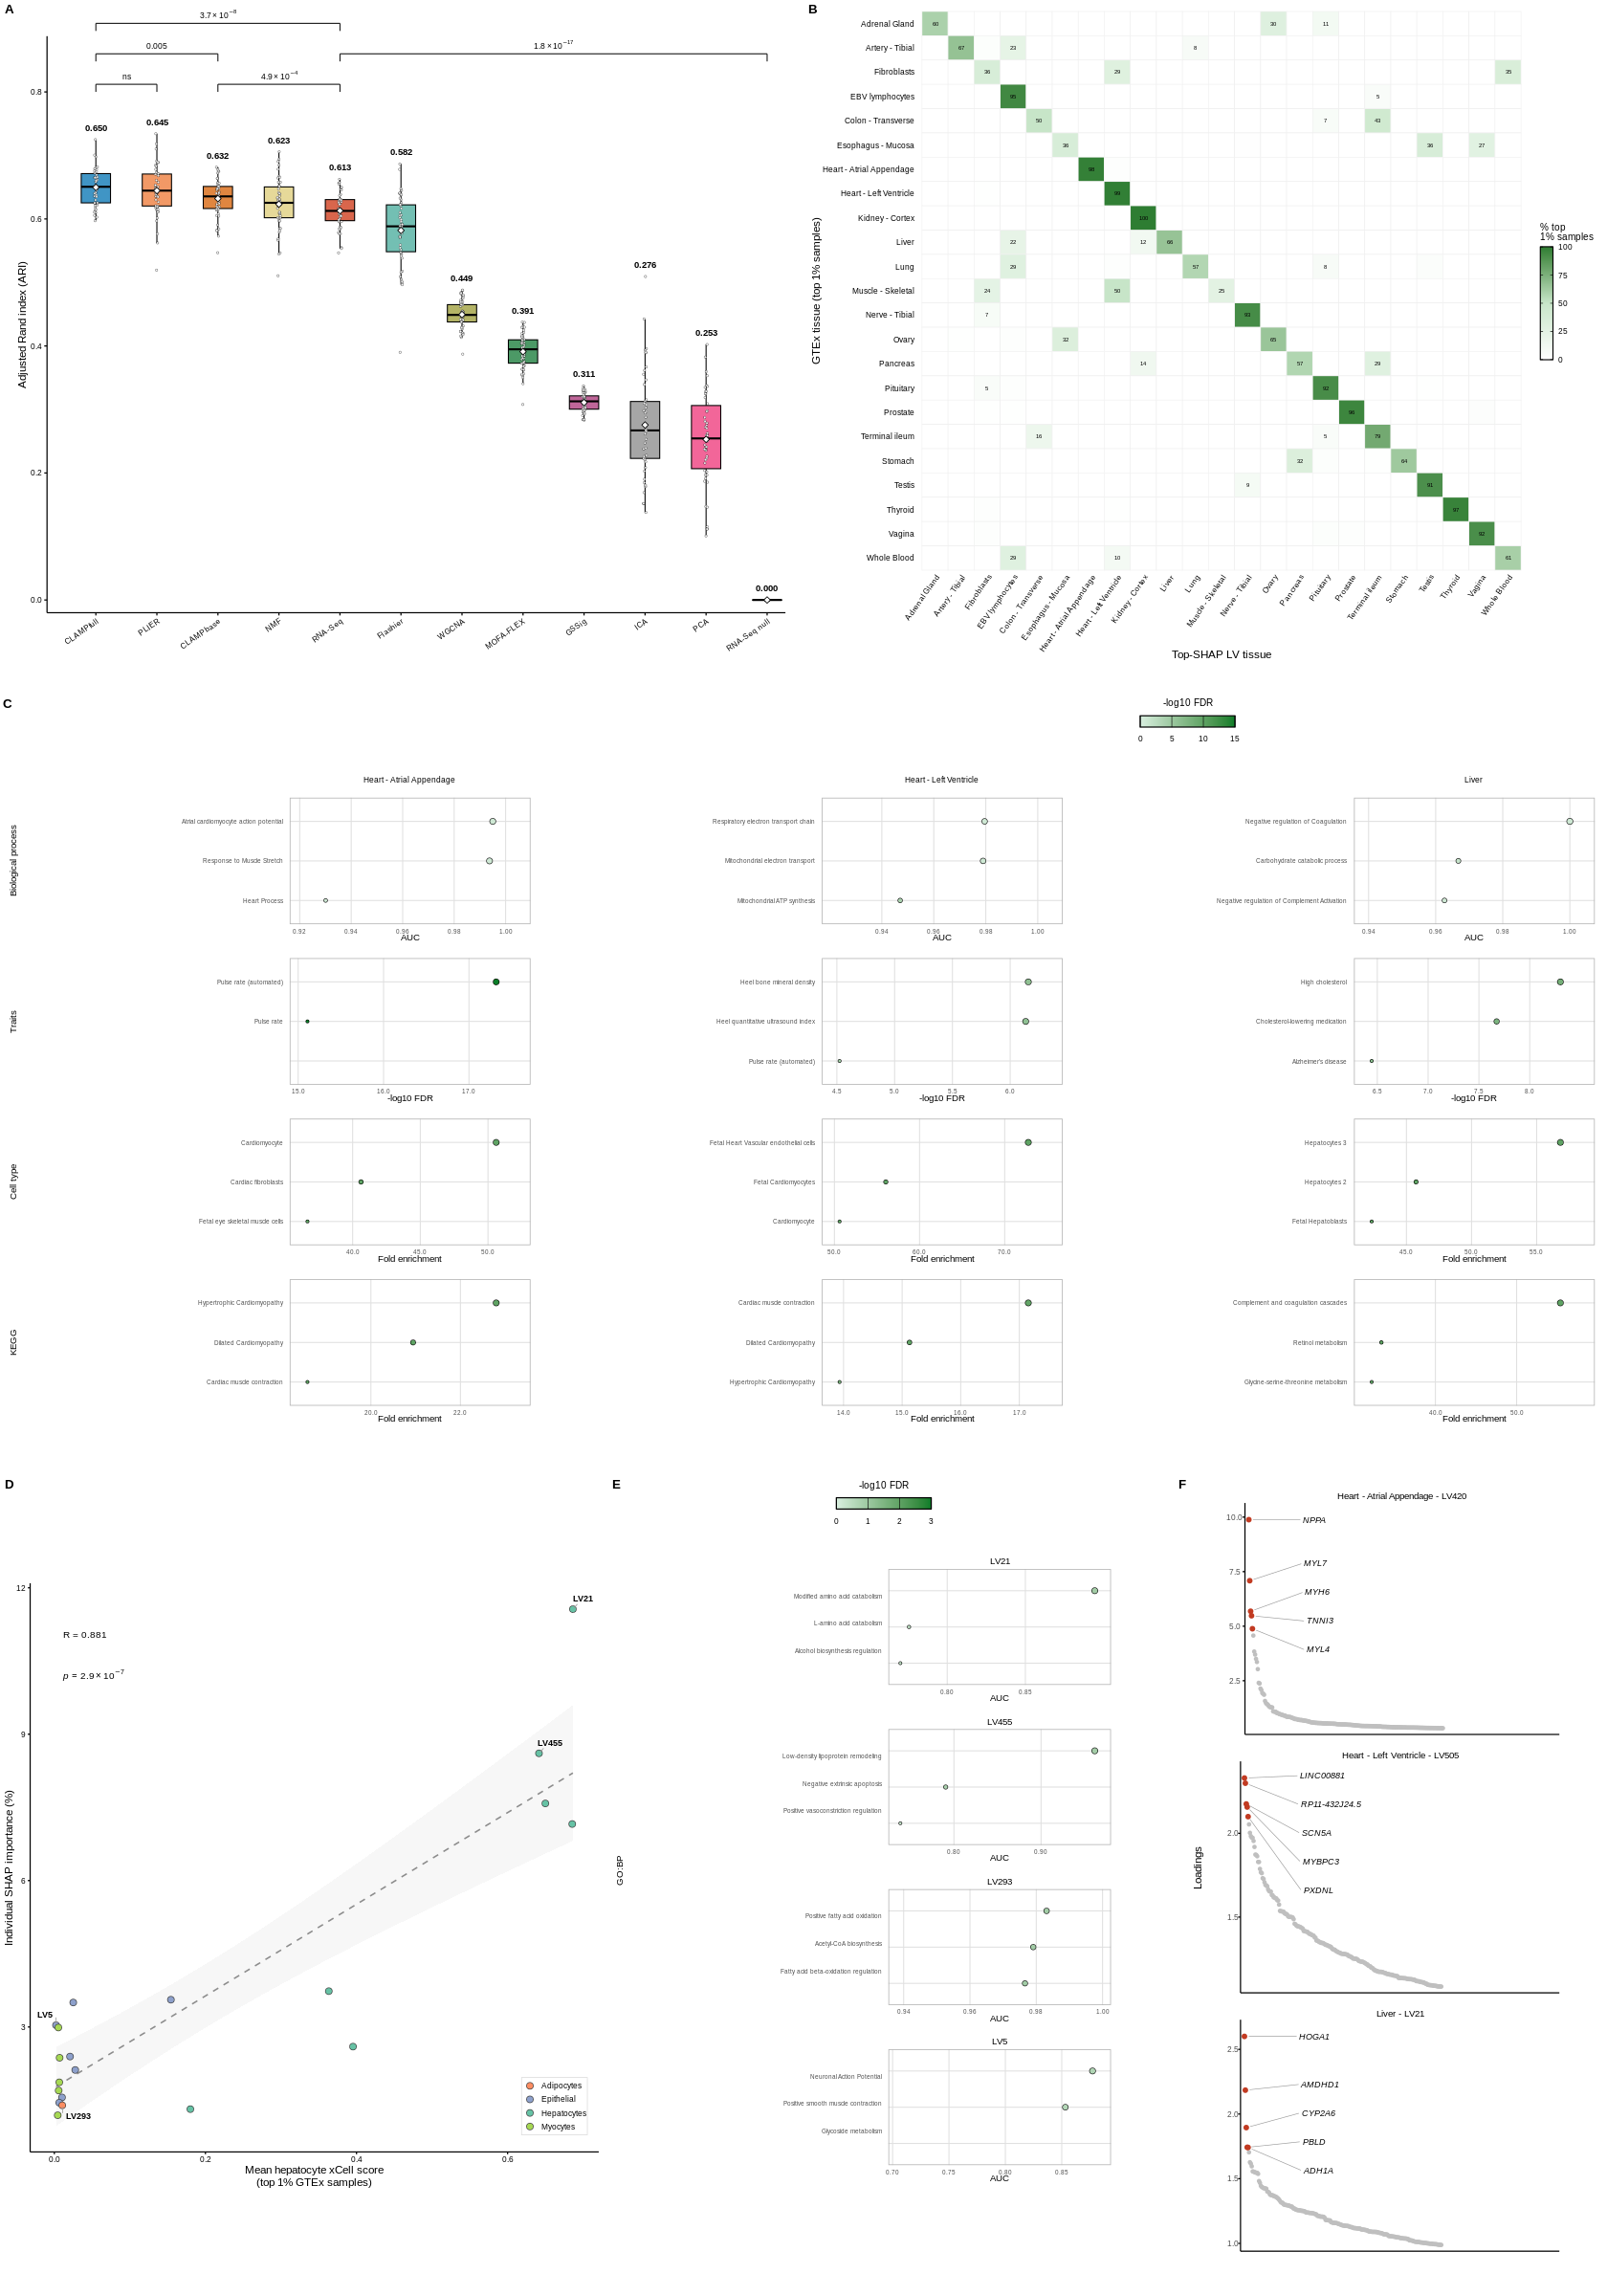

In [12]:
FIG_W <- 183
FIG_H <- 230

dir.create(PANEL_DIR, recursive = TRUE, showWarnings = FALSE)
options(repr.plot.width = 14, repr.plot.height = 20)

# ── Panel B: heatmap now carries its own right-side legend ───────────────
panel_newB <- plot_C_heatmap   # legend is built into the heatmap theme

# ── Panel A: boxplot ──────────────────────────────────────────────────────
panel_newA <- plot_B

# ── Row 1: A + B ──────────────────────────────────────────────────────────
row1 <- plot_grid(
    panel_newA, panel_newB,
    ncol = 2, rel_widths = c(1, 1),
    labels = c('A', 'B'), label_size = 8, label_fontface = 'bold',
    label_fontfamily = 'Helvetica'
)

# ── Panel C: 3-column tissue enrichment block ─────────────────────────────
grob_C_core <- cowplot::as_grob(plot_C_core)
grob_D_core <- cowplot::as_grob(plot_D_core)
grob_E_core <- cowplot::as_grob(plot_E_core)

# Column headers centered over plot area (left pad = 1 - plot_width = 0.46)
mk_col_title <- function(txt) {
    plot_grid(
        ggdraw(),   # spacer matching y-axis label area
        ggdraw() + draw_label(txt, size = PANEL_C_TITLE_SIZE, fontfamily = 'Helvetica',
                              fontface = 'plain', vjust = 0.5, hjust = 0.5),
        ncol = 2, rel_widths = c(0.54, 0.46)
    )
}
col1_titled <- plot_grid(mk_col_title('Heart - Atrial Appendage'), grob_C_core,
                         ncol = 1, rel_heights = c(0.05, 1))
col2_titled <- plot_grid(mk_col_title('Heart - Left Ventricle'),   grob_D_core,
                         ncol = 1, rel_heights = c(0.05, 1))
col3_titled <- plot_grid(mk_col_title('Liver'),                    grob_E_core,
                         ncol = 1, rel_heights = c(0.05, 1))

panel_C_3col <- plot_grid(col1_titled, col2_titled, col3_titled, ggdraw(),
                           ncol = 4, rel_widths = c(1, 1, 1, 0.02))

# Compact horizontal colorbar, matched to panel E and aligned top-right
panel_C_legend_h   <- make_dotplot_colorbar(ROW2_FILL_LIMITS, ROW2_FILL_BREAKS)
panel_C_legend_row <- plot_grid(ggdraw(), panel_C_legend_h, ggdraw(),
                                ncol = 3, rel_widths = c(0.58, 0.32, 0.10))
panel_C_block      <- plot_grid(panel_C_legend_row, panel_C_3col, ncol = 1, rel_heights = c(0.10, 1))

panel_newC <- ggdraw(panel_C_block) +
    draw_plot_label('C', x = 0, y = 1, size = 8, family = 'Helvetica',
                    fontface = 'bold', hjust = -0.3, vjust = 1.2)

# ── Panel E: LV dotplots with matched top-right legend ───────────────────
grob_G_stack <- cowplot::as_grob(plot_G_stack)
g_axis <- ggdraw() + draw_label('GO:BP', x = 0.95, angle = 90, fontface = 'plain',
                                 fontfamily = 'Helvetica', size = PANEL_C_AXIS_TITLE_SIZE)
panel_E_core <- plot_grid(g_axis, grob_G_stack, ncol = 2, rel_widths = c(0.025, 1))

panel_E_legend_h <- make_dotplot_colorbar(LV_FILL_LIMITS, LV_FILL_BREAKS)
panel_E_leg_row  <- plot_grid(ggdraw(), panel_E_legend_h, ggdraw(),
                              ncol = 3, rel_widths = c(0.24, 0.62, 0.14))
panel_newE <- plot_grid(panel_E_leg_row, panel_E_core, ggdraw(), ncol = 1,
                        rel_heights = c(0.11, 0.90, 0.10))

# ── Panel D: scatter (old F) ──────────────────────────────────────────────
panel_newD <- plot_F

# ── Panel F: loading plots (old H) ───────────────────────────────────────
panel_newF <- plot_H

# ── Row 3: D + E + F ──────────────────────────────────────────────────────
row3 <- plot_grid(
    panel_newD, panel_newE, ggdraw(), panel_newF,
    ncol = 4, rel_widths = c(1.18, 0.98, 0.12, 0.84), align = 'h', axis = 'tb',
    labels = c('D', 'E', '', 'F'), label_size = 8, label_fontface = 'bold',
    label_fontfamily = 'Helvetica'
)

# ── Final figure ──────────────────────────────────────────────────────────
fig2 <- plot_grid(
    row1, ggdraw(), panel_newC, ggdraw(), row3,
    ncol = 1, rel_heights = c(1, 0.055, 1.10, 0.075, 1.24)
)

ggsave(file.path(PANEL_DIR, 'fig2.pdf'), fig2,
       width = FIG_W, height = FIG_H, units = 'mm', device = cairo_pdf, bg = 'white')
ggsave(file.path(PANEL_DIR, 'fig2.png'), fig2,
       width = FIG_W, height = FIG_H, units = 'mm', dpi = 300, bg = 'white')
fig2
